# Information of the notebook
---

This notebook is prepared for the **Capstone BBO Stage 1** Project.

The aim of the Capstone BBO Stage 1 is to build the skills and habits required for the BBO challenge in Stage 2.

For this experiment, **House Prices - Advanced Regression Techniques, link from Kaggle**  is chosen from Kaggle.

(https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview Links to an external site.)

This notebook contains the exploratory data analysis for the **train.csv** file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Read the CSV file
CSV = pd.read_csv("train.csv")
df= pd.DataFrame(CSV)

In [47]:
# Retrieving the column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [48]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [49]:
# Combine all building area
df["Area"] = df["1stFlrSF"] + df["2ndFlrSF"]+df["GrLivArea"]

# Heatmap

In [3]:
# Select int64 dtype parameters for heatmap review
X = df[['MSSubClass', 
'LotArea', 
'OverallQual', 
'OverallCond', 
'YearBuilt', 
'YearRemodAdd', 
'BsmtFinSF1', 
'BsmtFinSF2', 
'BsmtUnfSF', 
'TotalBsmtSF', 
'1stFlrSF', 
'2ndFlrSF', 
'LowQualFinSF', 
'GrLivArea', 
'BsmtFullBath', 
'BsmtHalfBath', 
'FullBath', 
'HalfBath', 
'BedroomAbvGr', 
'KitchenAbvGr', 
'TotRmsAbvGrd', 
'Fireplaces', 
'GarageCars', 
'GarageArea', 
'WoodDeckSF', 
'OpenPorchSF', 
'EnclosedPorch', 
'3SsnPorch', 
'ScreenPorch', 
'PoolArea', 
'MiscVal', 
'MoSold', 
'YrSold',
'SalePrice']]

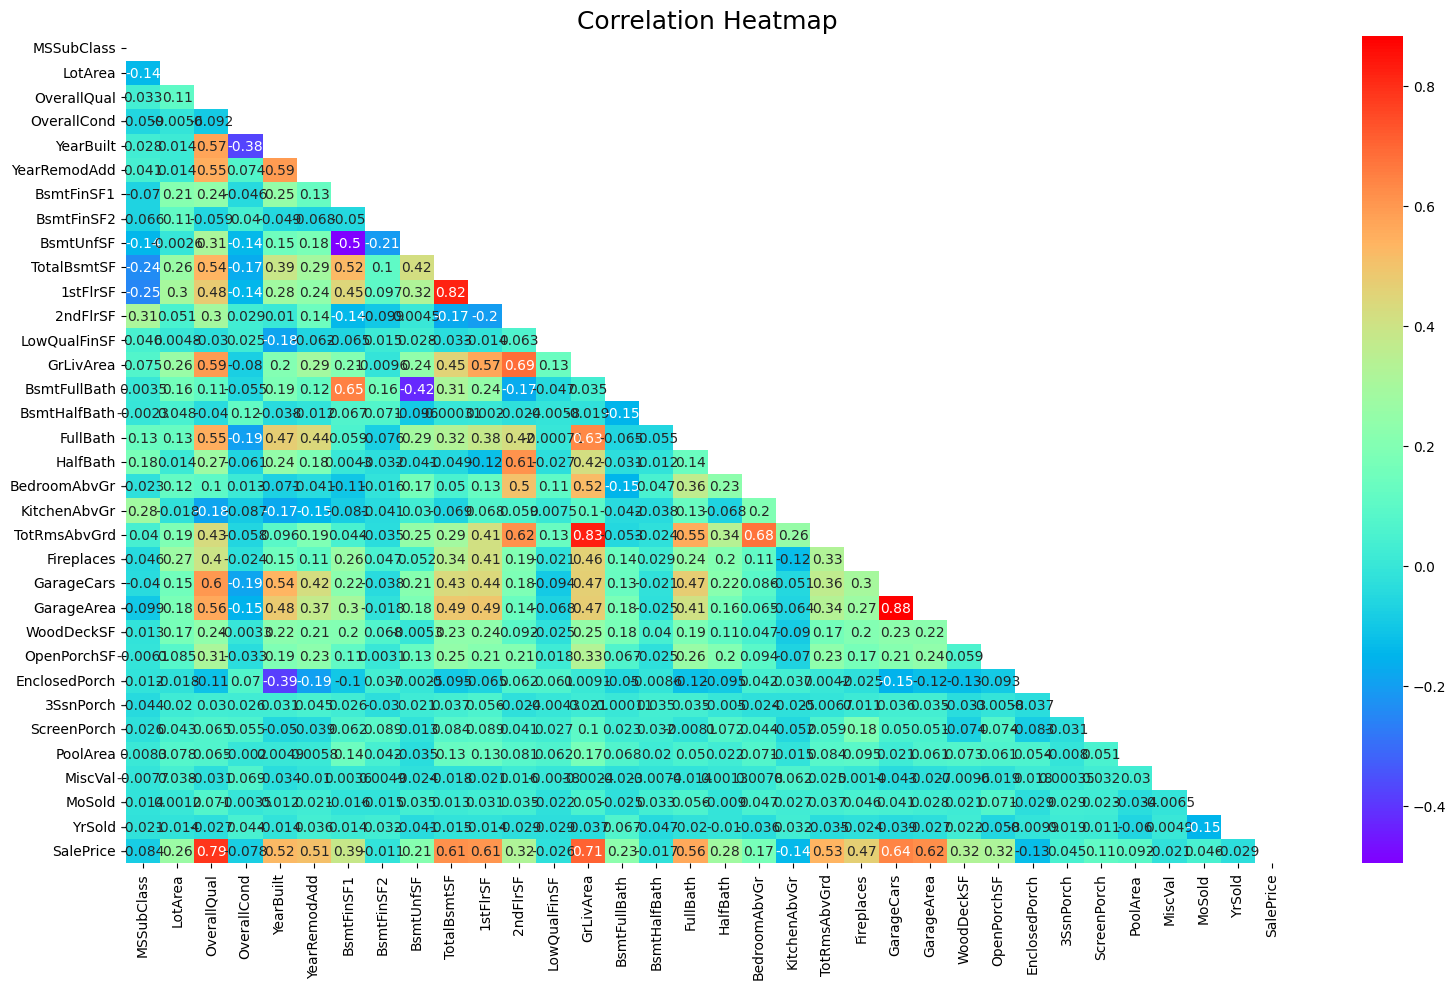

In [4]:
fig = plt.figure(figsize=(16,10))

corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig = sns.heatmap(corr, mask=mask, annot=True, cmap='rainbow')
fig.set_title('Correlation Heatmap', size=18)
plt.tight_layout()

# Pair Plots

In [5]:
# Select highly correlated features only 
Y = df[[
'OverallQual', 
'YearBuilt', 
'YearRemodAdd', 
'TotalBsmtSF', 
'1stFlrSF', 
'2ndFlrSF', 
'GrLivArea', 
'FullBath', 
'HalfBath', 
'TotRmsAbvGrd', 
'Fireplaces', 
'GarageCars', 
'GarageArea', 
'SalePrice']]

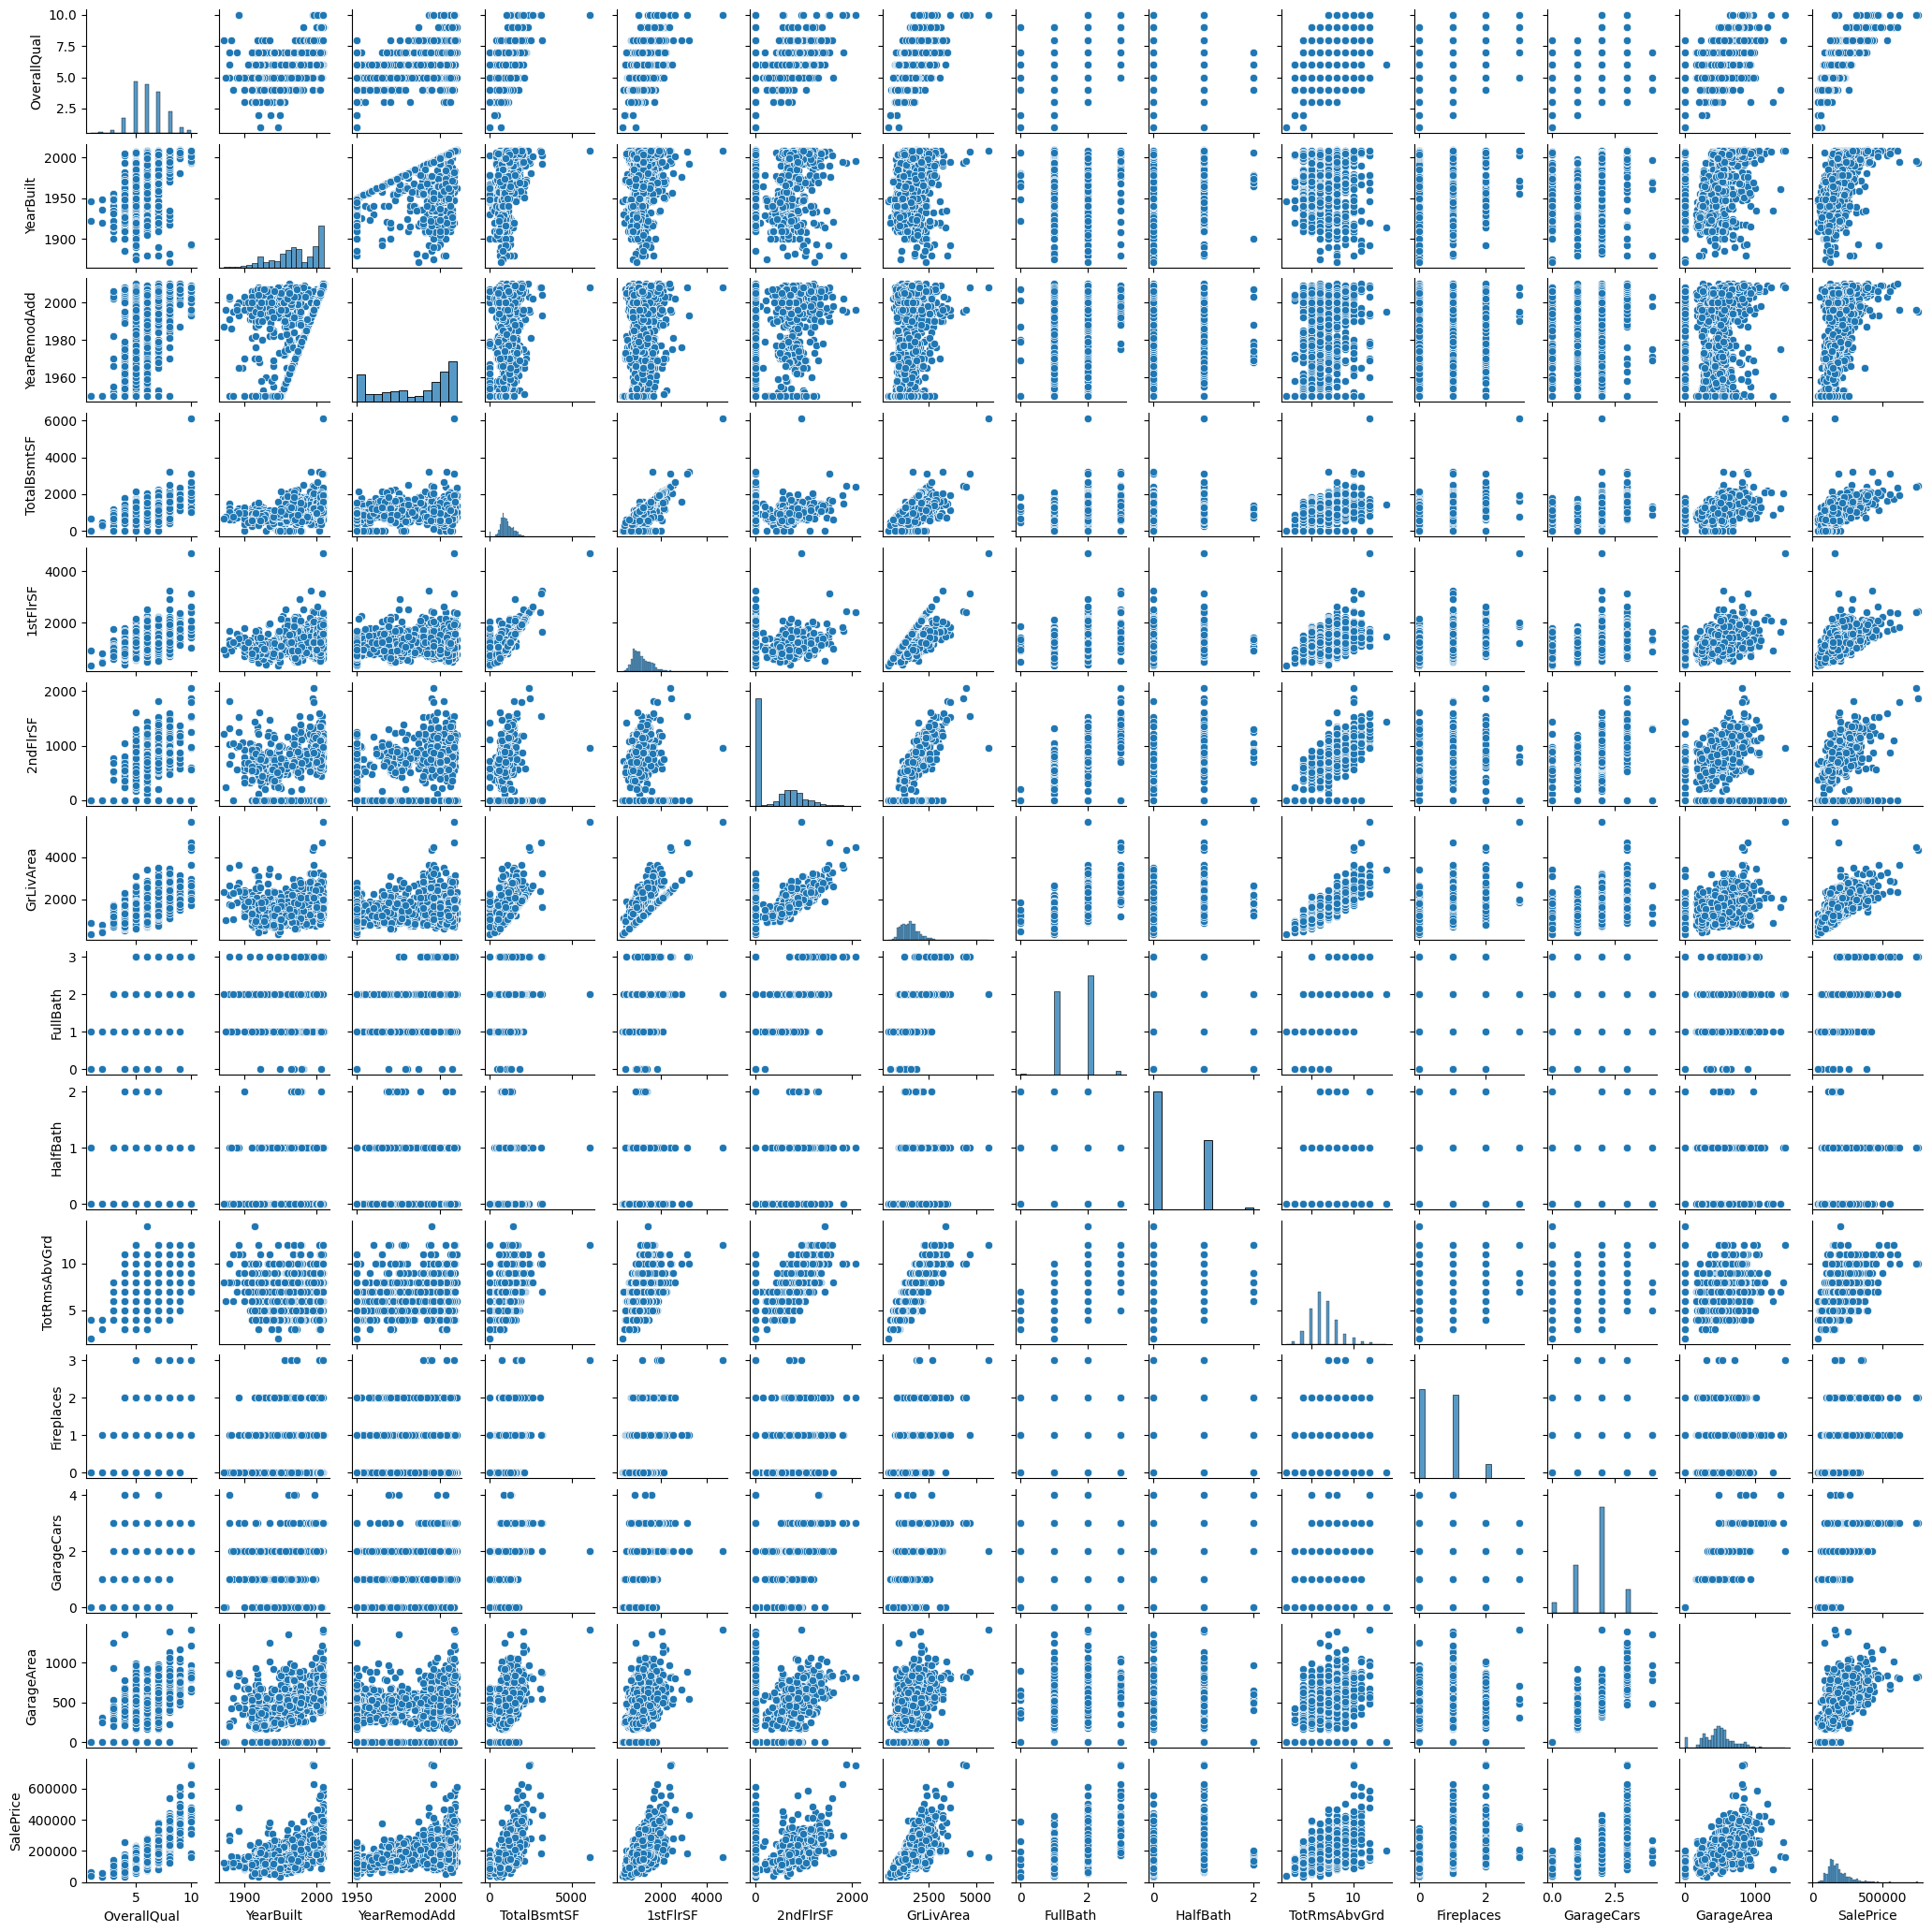

In [6]:
g = sns.pairplot(Y, diag_kind="hist", height=1.5)

# Sale

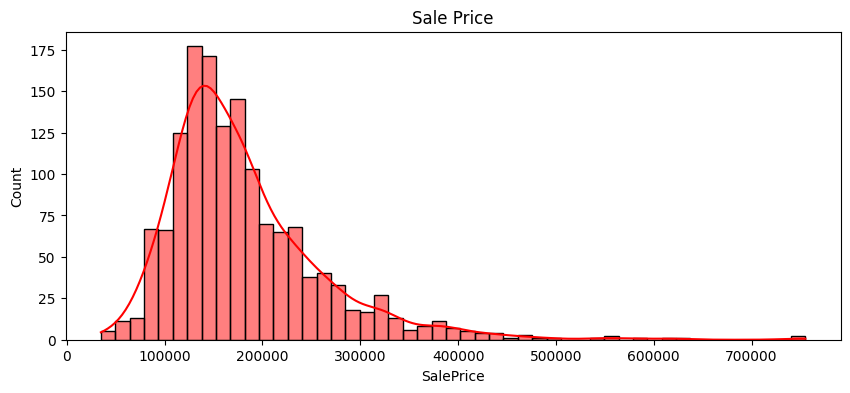

In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(df['SalePrice'], kde=True, color='red')
plt.title('Sale Price')
plt.show()

Text(0.5, 1.0, 'Year Sold')

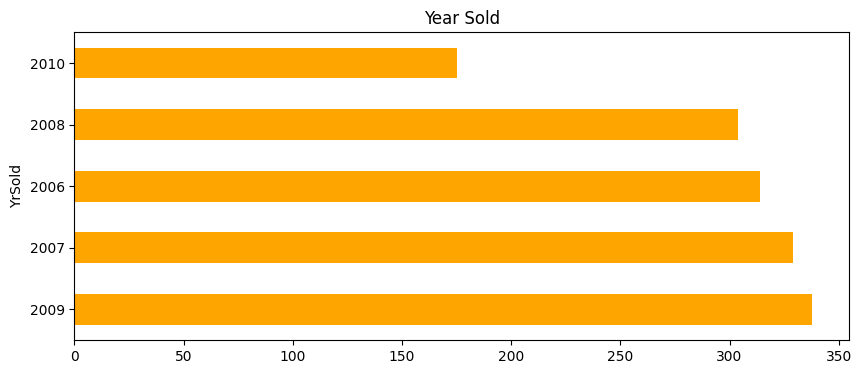

In [7]:
plt.figure(figsize=(10, 4))
df.YrSold.value_counts().plot(kind='barh', color='orange')
plt.title('Year Sold')

Text(0.5, 1.0, 'Month Sold')

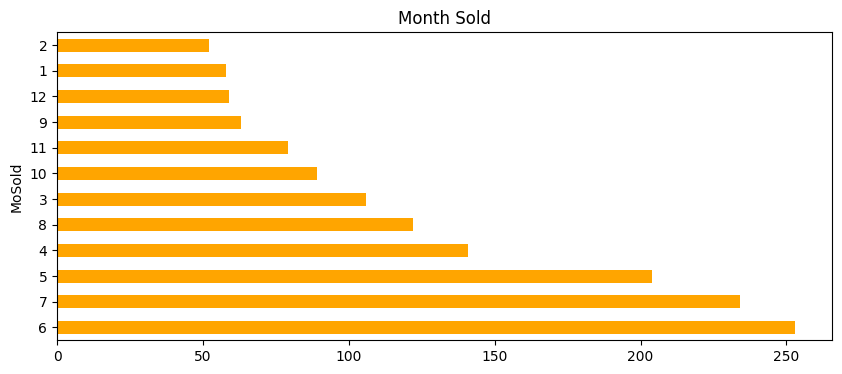

In [8]:
plt.figure(figsize=(10, 4))
df.MoSold.value_counts().plot(kind='barh', color='orange')
plt.title('Month Sold')

Text(0.5, 1.0, 'Type of sale')

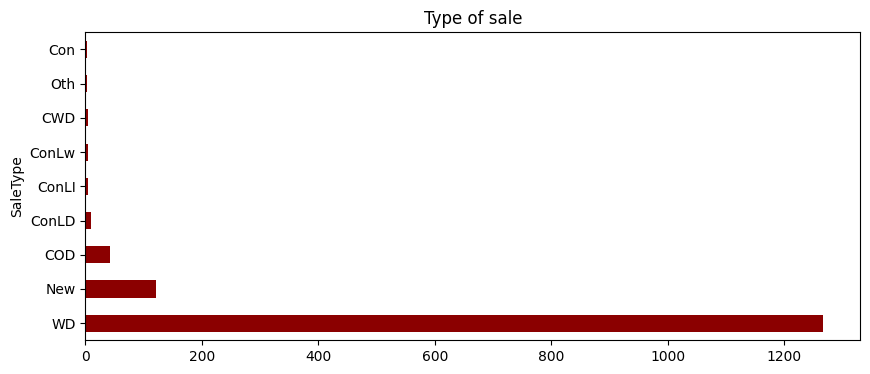

In [9]:
plt.figure(figsize=(10, 4))
df.SaleType.value_counts().plot(kind='barh', color='darkred')
plt.title('Type of sale')

Text(0.5, 1.0, 'Condition of sale')

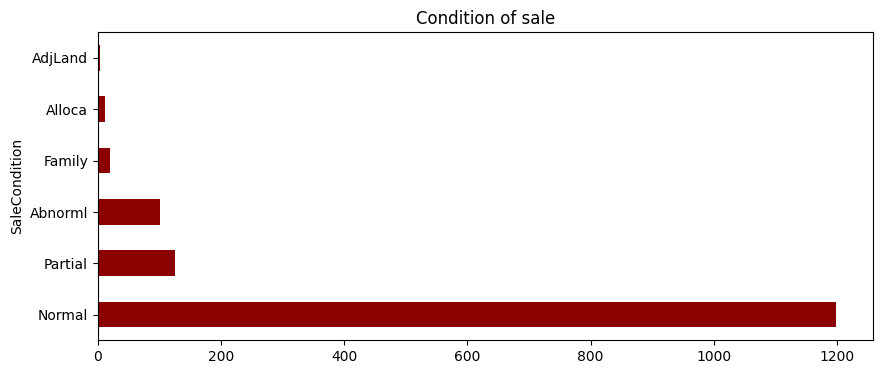

In [10]:
plt.figure(figsize=(10, 4))
df.SaleCondition.value_counts().plot(kind='barh', color='darkred')
plt.title('Condition of sale')

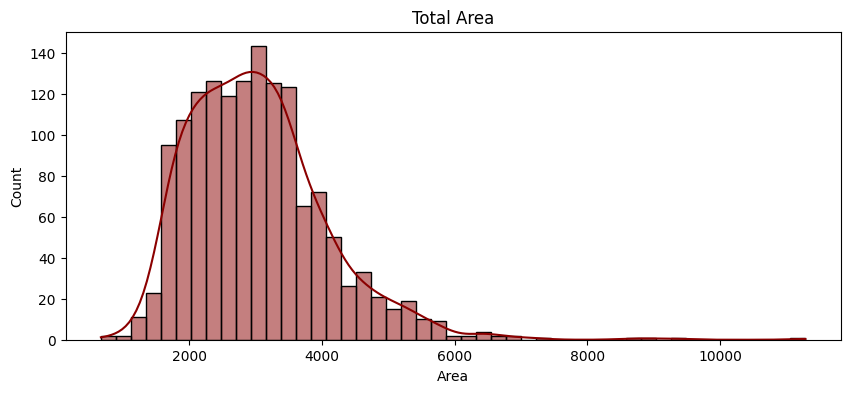

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Area'], kde=True, color='darkred')
plt.title('Total Area')
plt.show()

# Critical Facts

Text(0.5, 1.0, 'Physical locations within Ames city limits')

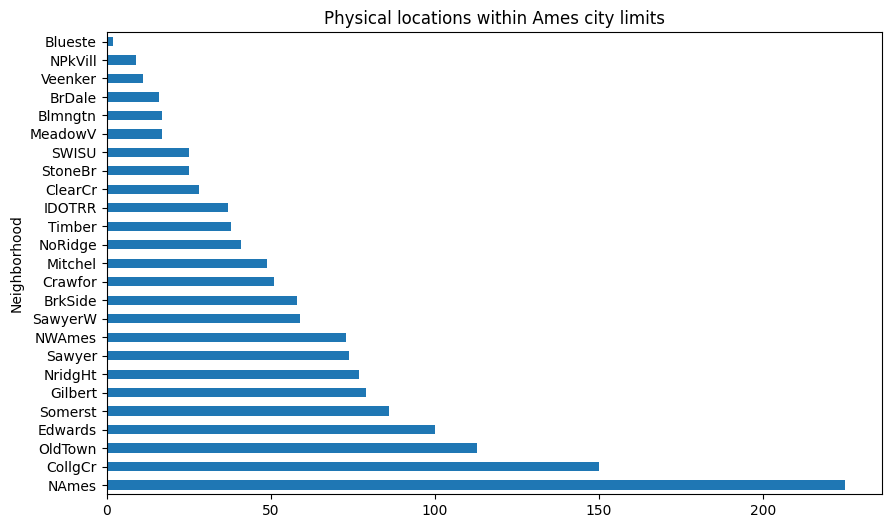

In [12]:
plt.figure(figsize=(10, 6))
df.Neighborhood.value_counts().plot(kind='barh')
plt.title('Physical locations within Ames city limits')

Text(0.5, 1.0, 'Type of Dwelling')

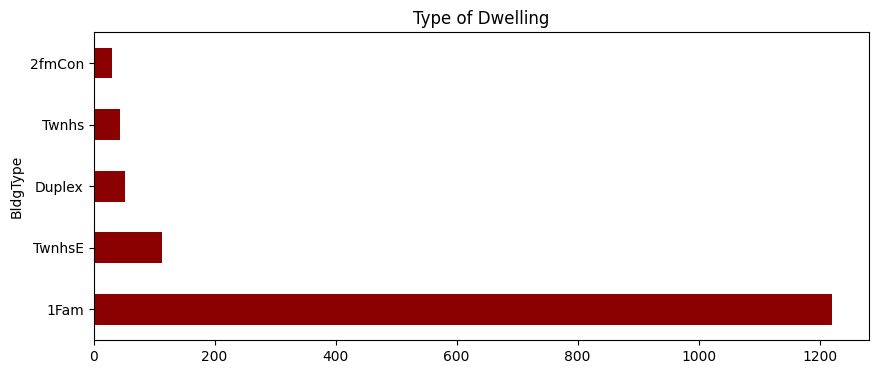

In [13]:
plt.figure(figsize=(10, 4))
df.BldgType.value_counts().plot(kind='barh', color='darkred')
plt.title('Type of Dwelling')

Text(0.5, 1.0, 'Style of Dwelling')

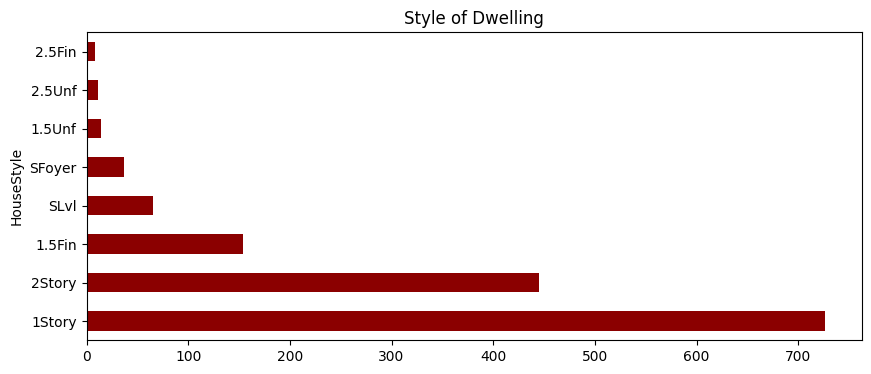

In [14]:
plt.figure(figsize=(10, 4))
df.HouseStyle.value_counts().plot(kind='barh', color='darkred')
plt.title('Style of Dwelling')

Text(0.5, 1.0, 'Size of garage in car capacity')

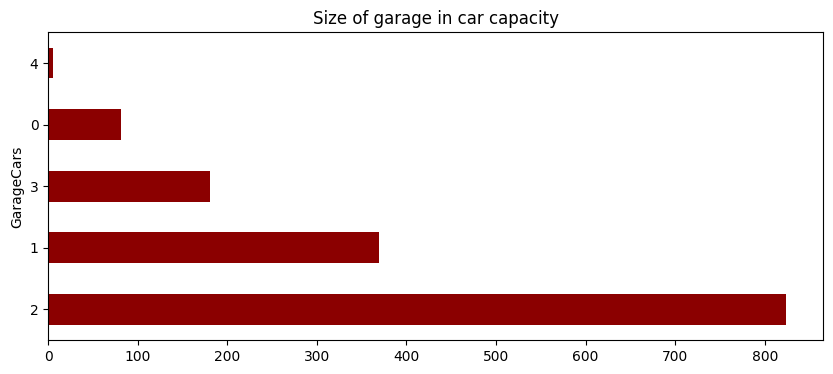

In [15]:
plt.figure(figsize=(10, 4))
df.GarageCars.value_counts().plot(kind='barh', color='darkred')
plt.title('Size of garage in car capacity')

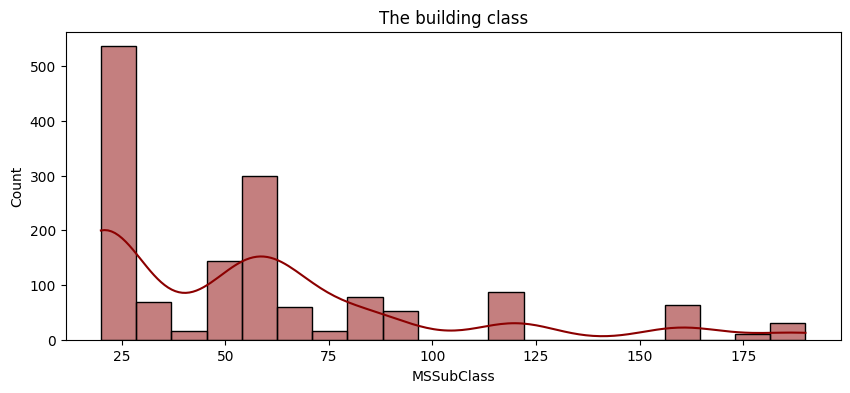

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(df['MSSubClass'], kde=True, color='darkred')
plt.title('The building class')
plt.show()

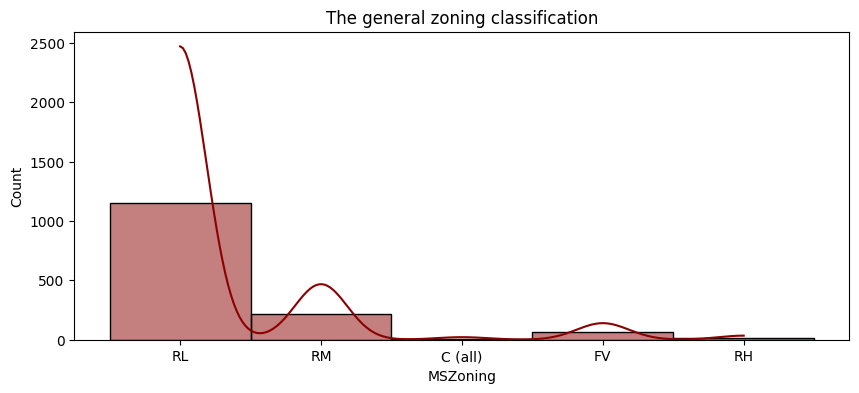

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(df['MSZoning'], kde=True, color='darkred')
plt.title('The general zoning classification')
plt.show()

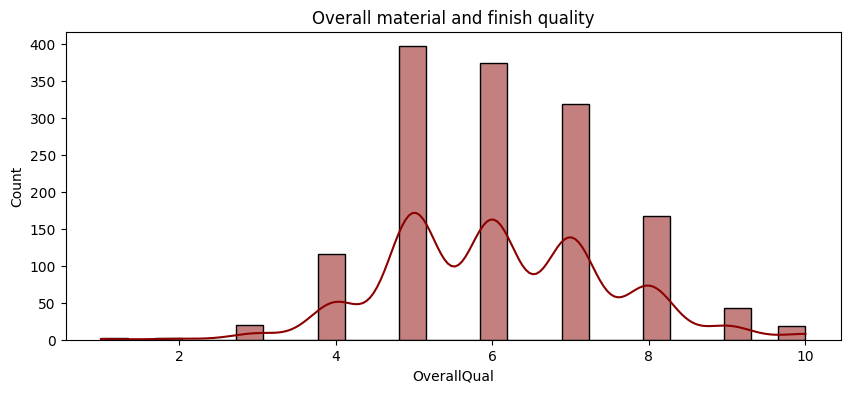

In [18]:
plt.figure(figsize=(10, 4))
sns.histplot(df['OverallQual'], kde=True, color='darkred')
plt.title('Overall material and finish quality')
plt.show()

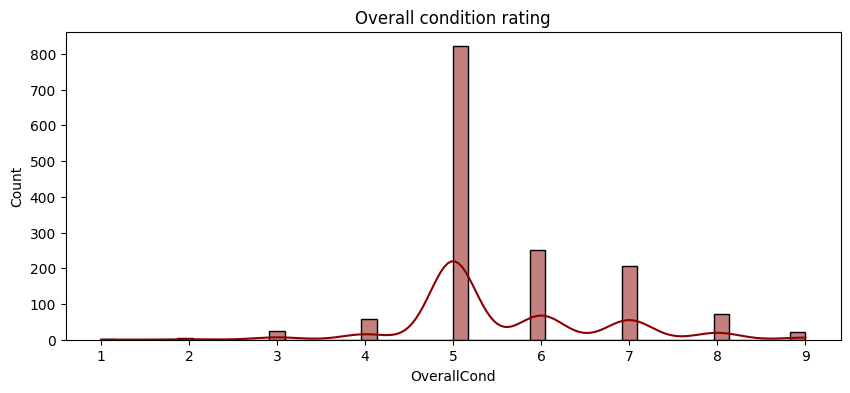

In [19]:
plt.figure(figsize=(10, 4))
sns.histplot(df['OverallCond'], kde=True, color='darkred')
plt.title('Overall condition rating')
plt.show()

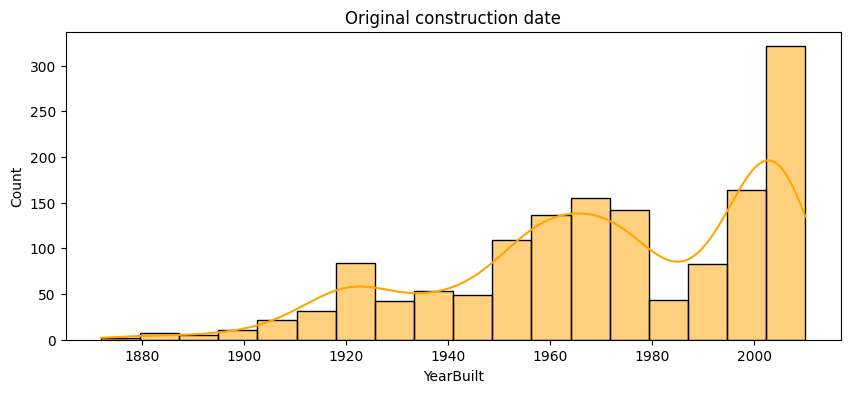

In [20]:
plt.figure(figsize=(10, 4))
sns.histplot(df['YearBuilt'], kde=True, color='orange')
plt.title('Original construction date')
plt.show()

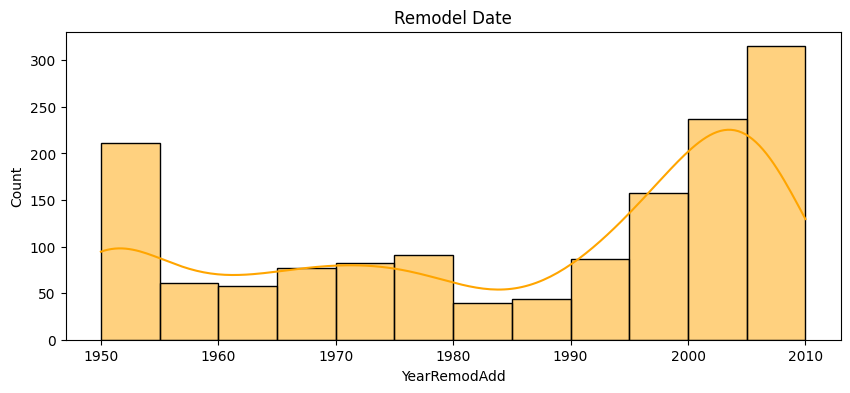

In [21]:
plt.figure(figsize=(10, 4))
sns.histplot(df['YearRemodAdd'], kde=True, color='orange')
plt.title('Remodel Date')
plt.show()

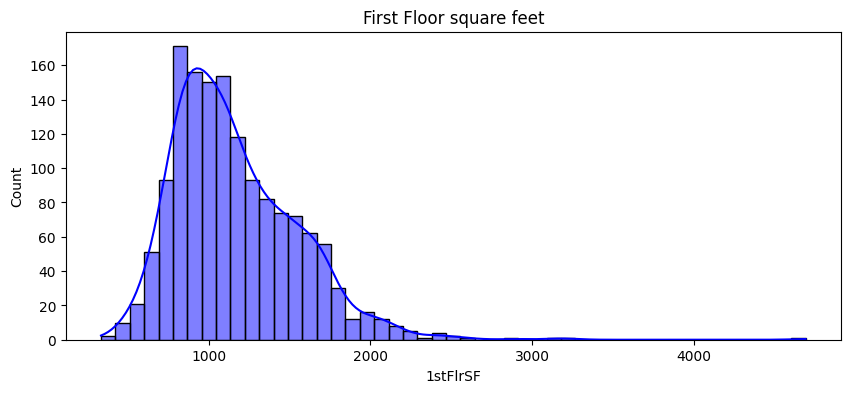

In [22]:
plt.figure(figsize=(10, 4))
sns.histplot(df['1stFlrSF'], kde=True, color='blue')
plt.title('First Floor square feet')
plt.show()

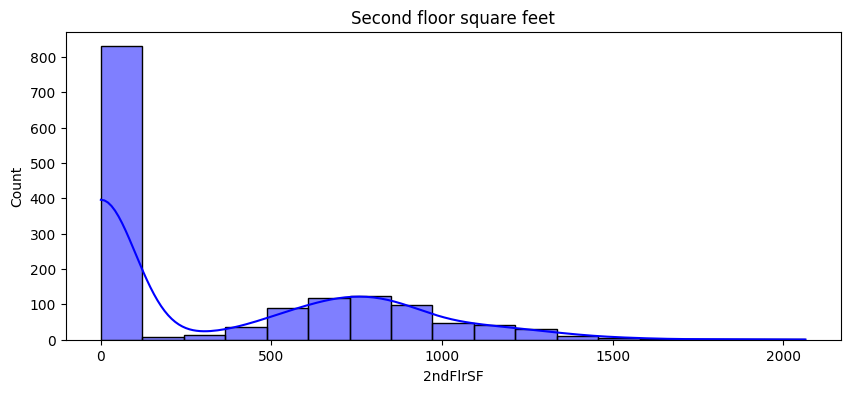

In [23]:
plt.figure(figsize=(10, 4))
sns.histplot(df['2ndFlrSF'], kde=True, color='blue')
plt.title('Second floor square feet')
plt.show()

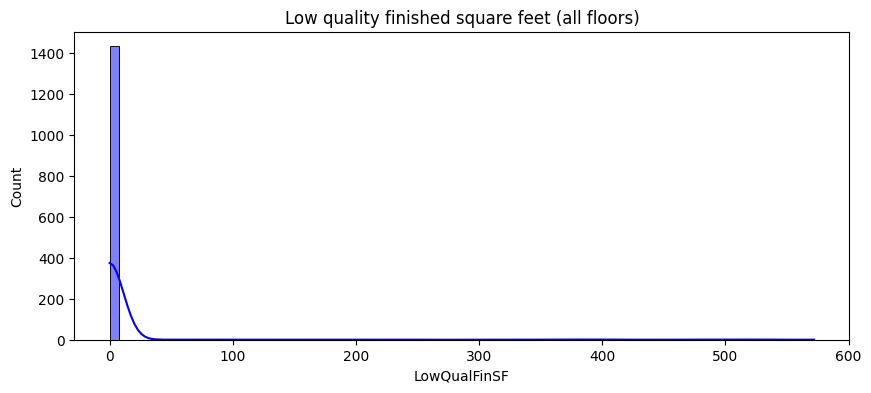

In [24]:
plt.figure(figsize=(10, 4))
sns.histplot(df['LowQualFinSF'], kde=True, color='blue')
plt.title('Low quality finished square feet (all floors)')
plt.show()

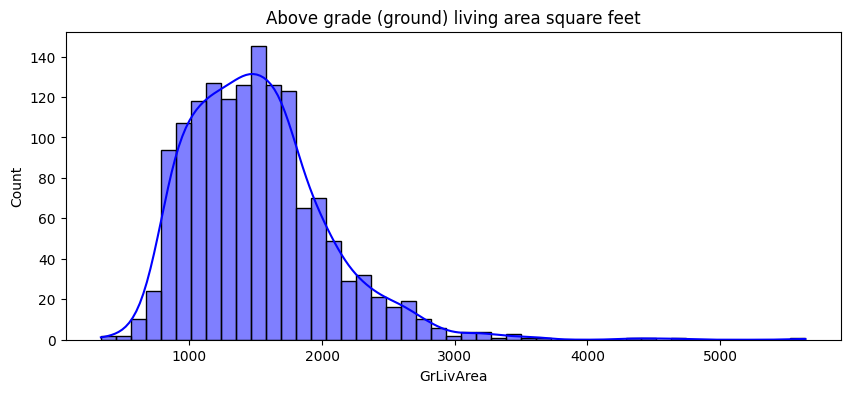

In [25]:
plt.figure(figsize=(10, 4))
sns.histplot(df['GrLivArea'], kde=True, color='blue')
plt.title('Above grade (ground) living area square feet')
plt.show()

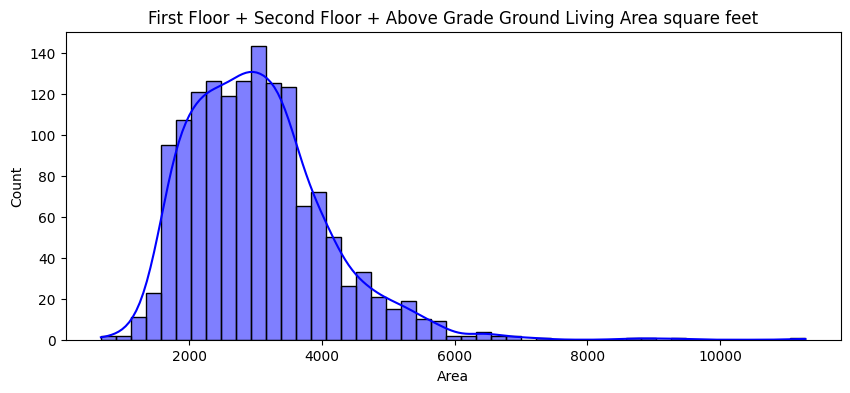

In [26]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Area'], kde=True, color='blue')
plt.title('First Floor + Second Floor + Above Grade Ground Living Area square feet')
plt.show()

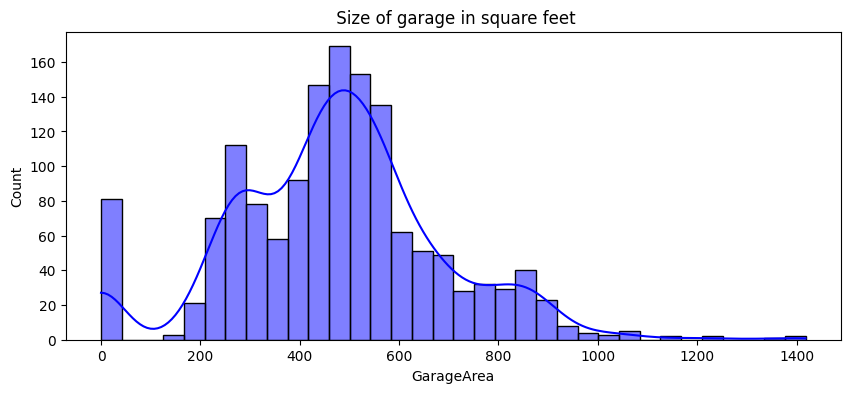

In [27]:
plt.figure(figsize=(10, 4))
sns.histplot(df['GarageArea'], kde=True, color='blue')
plt.title(' Size of garage in square feet')
plt.show()

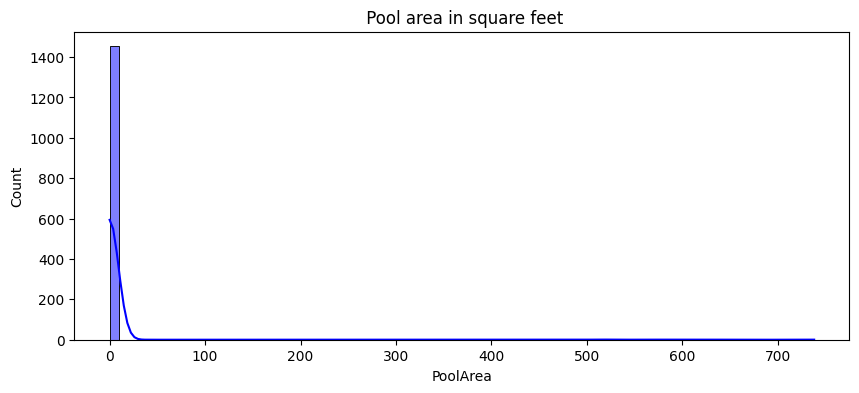

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(df['PoolArea'], kde=True, color='blue')
plt.title(' Pool area in square feet')
plt.show()

# Correlation

Text(0.5, 1.0, 'Total Building Area vs Sale Price')

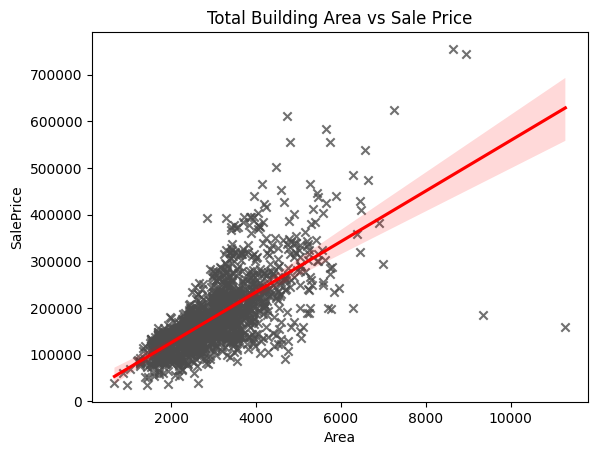

In [29]:
sns.regplot(data=df, x="Area", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Total Building Area vs Sale Price')

Text(0.5, 1.0, 'Size of garage in square feet vs Sale Price')

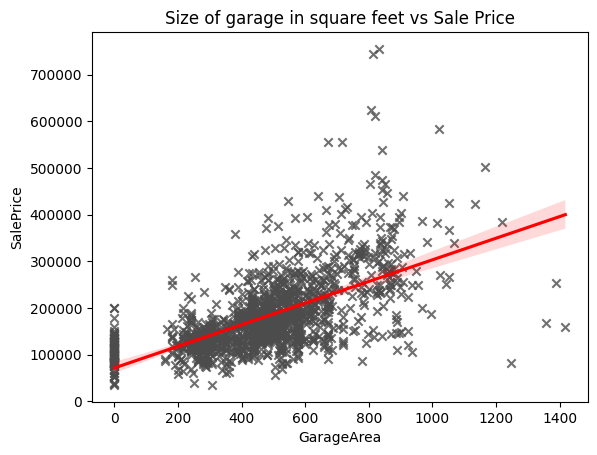

In [30]:
sns.regplot(data=df, x="GarageArea", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Size of garage in square feet vs Sale Price')

Text(0.5, 1.0, 'Pool area in square feet vs Sale Price')

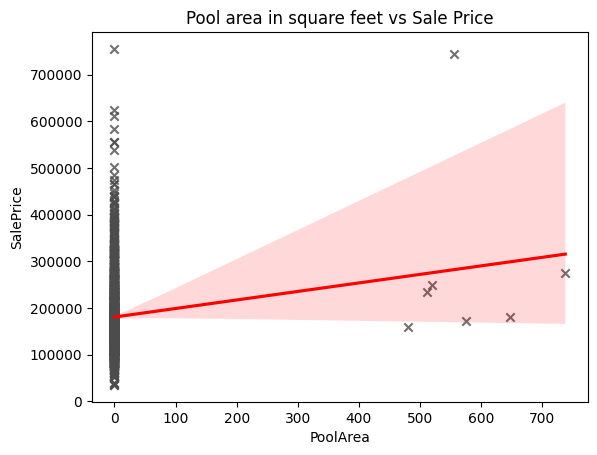

In [31]:
sns.regplot(data=df, x="PoolArea", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Pool area in square feet vs Sale Price')

Text(0.5, 1.0, 'The building class vs Sale Price')

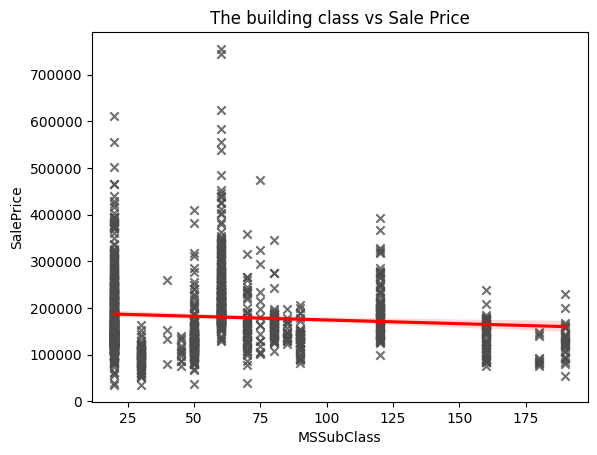

In [32]:
sns.regplot(data=df, x="MSSubClass", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('The building class vs Sale Price')

Text(0.5, 1.0, 'Overall material and finish quality vs Sale Price')

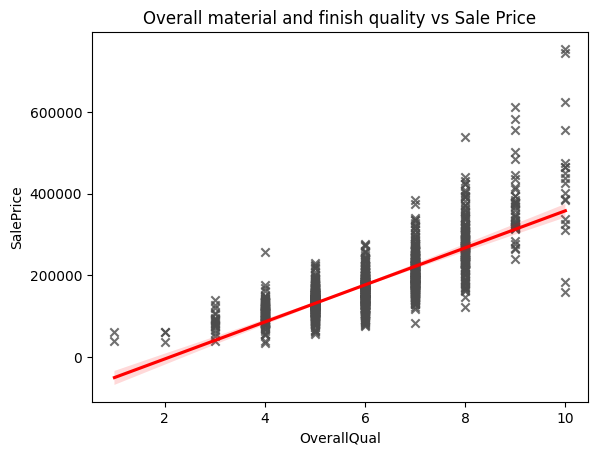

In [33]:
sns.regplot(data=df, x="OverallQual", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Overall material and finish quality vs Sale Price')

Text(0.5, 1.0, 'Overall condition rating vs Sale Price')

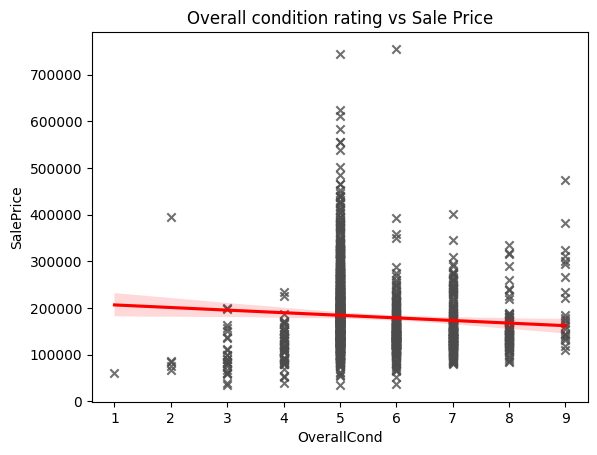

In [34]:
sns.regplot(data=df, x="OverallCond", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Overall condition rating vs Sale Price')

Text(0.5, 1.0, 'Year Sold vs Sale Price')

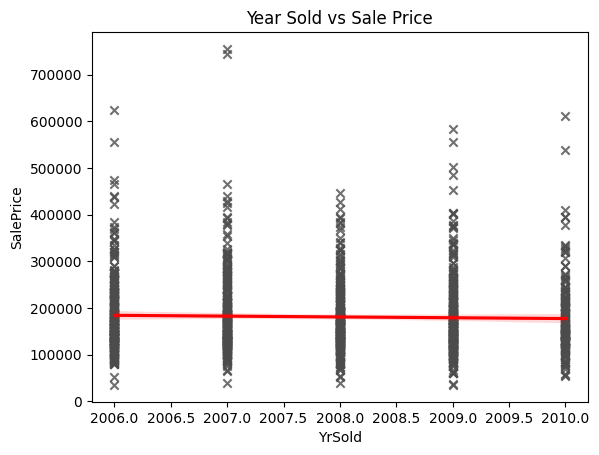

In [35]:
sns.regplot(data=df, x="YrSold", y="SalePrice",
            ci=99, marker="x", color=".3", line_kws=dict(color="r"),)
plt.title('Year Sold vs Sale Price')

# Sub data

<Axes: xlabel='Area', ylabel='SalePrice'>

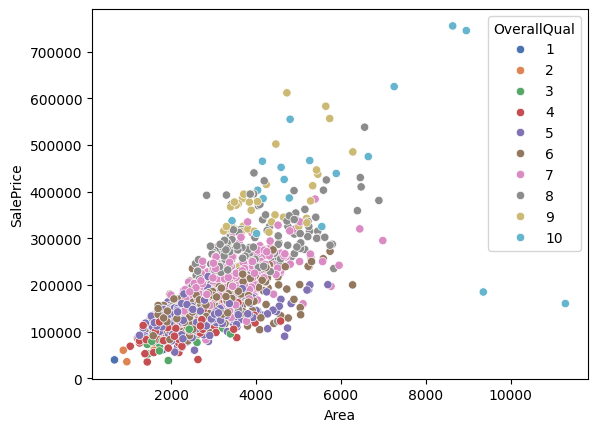

In [36]:
sns.scatterplot(data=df, x="Area", y="SalePrice", hue="OverallQual", palette="deep")

<Axes: xlabel='Area', ylabel='SalePrice'>

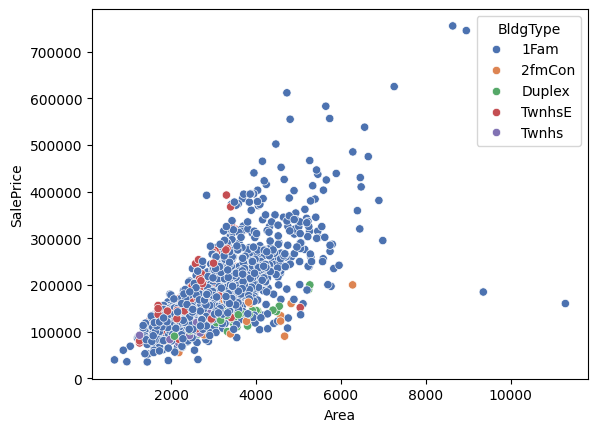

In [37]:
sns.scatterplot(data=df, x="Area", y="SalePrice", hue="BldgType", palette="deep")

<Axes: xlabel='Area', ylabel='SalePrice'>

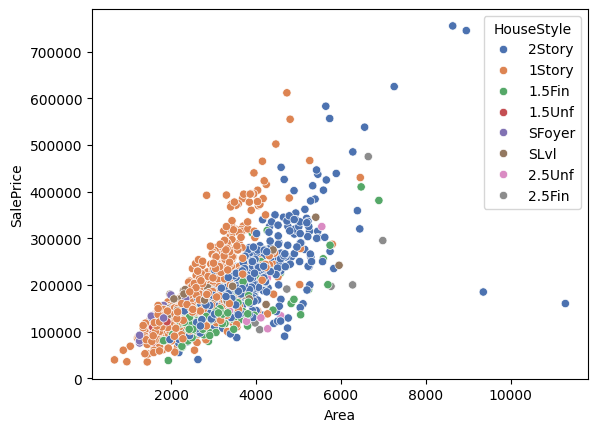

In [38]:
sns.scatterplot(data=df, x="Area", y="SalePrice", hue="HouseStyle", palette="deep")

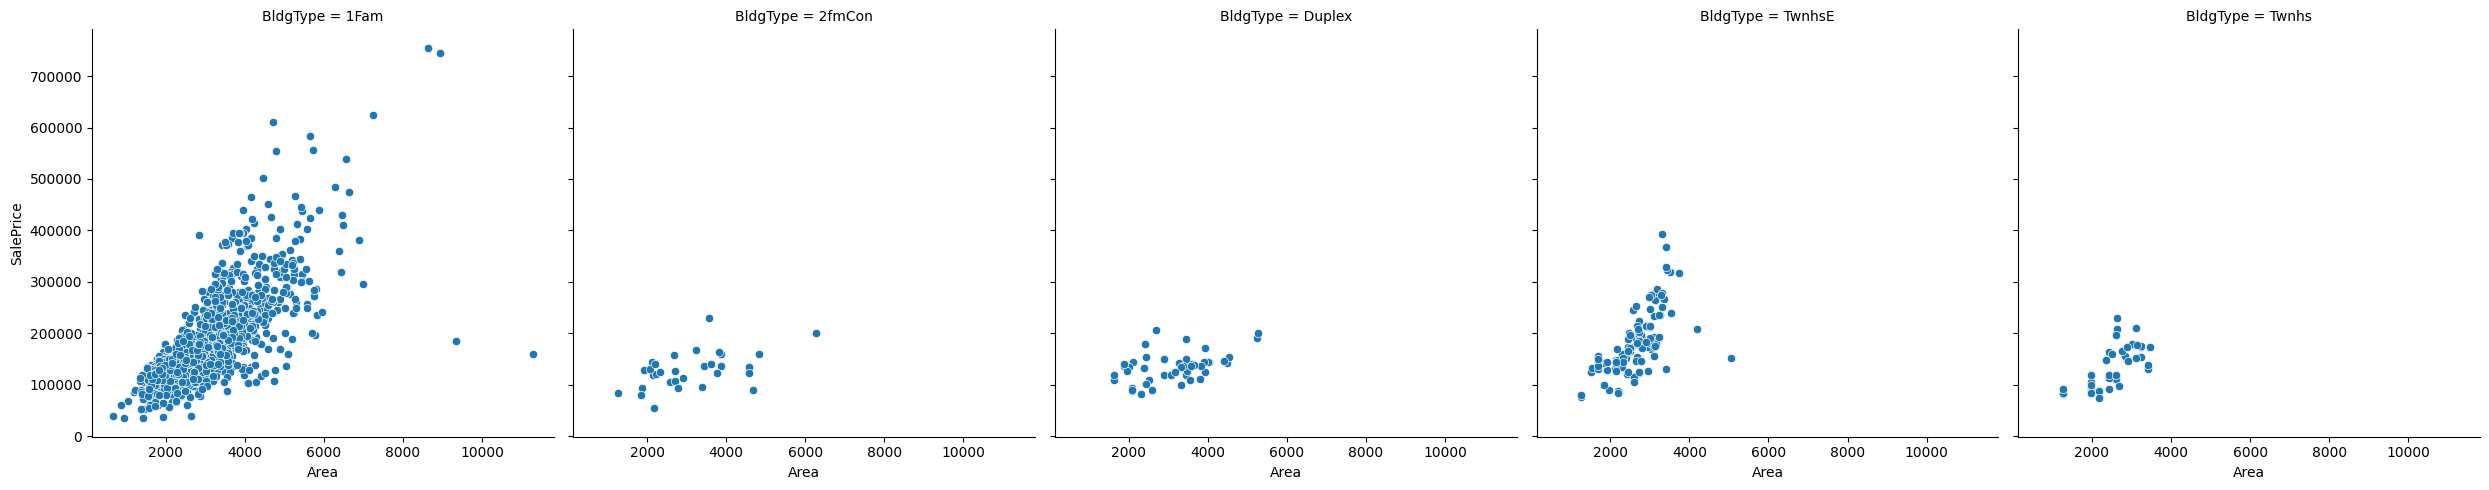

In [39]:
sns.relplot(data=df, x="Area", y="SalePrice", col="BldgType", kind="scatter")

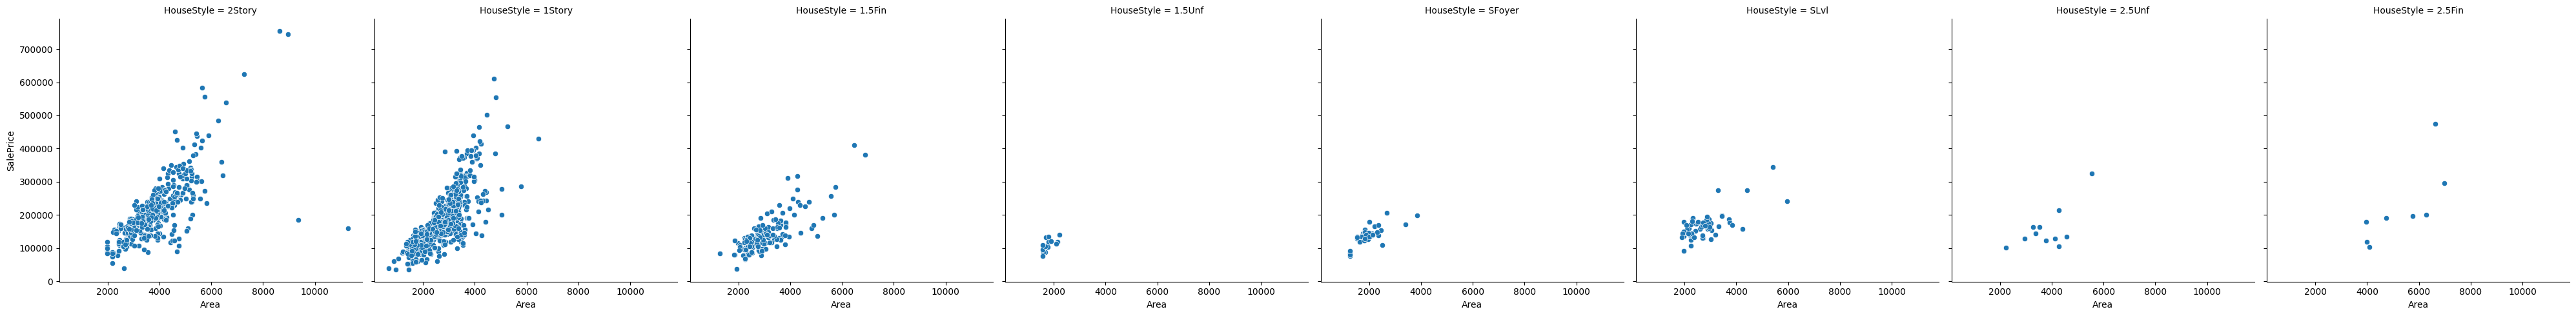

In [40]:
sns.relplot(data=df, x="Area", y="SalePrice", col="HouseStyle", kind="scatter")

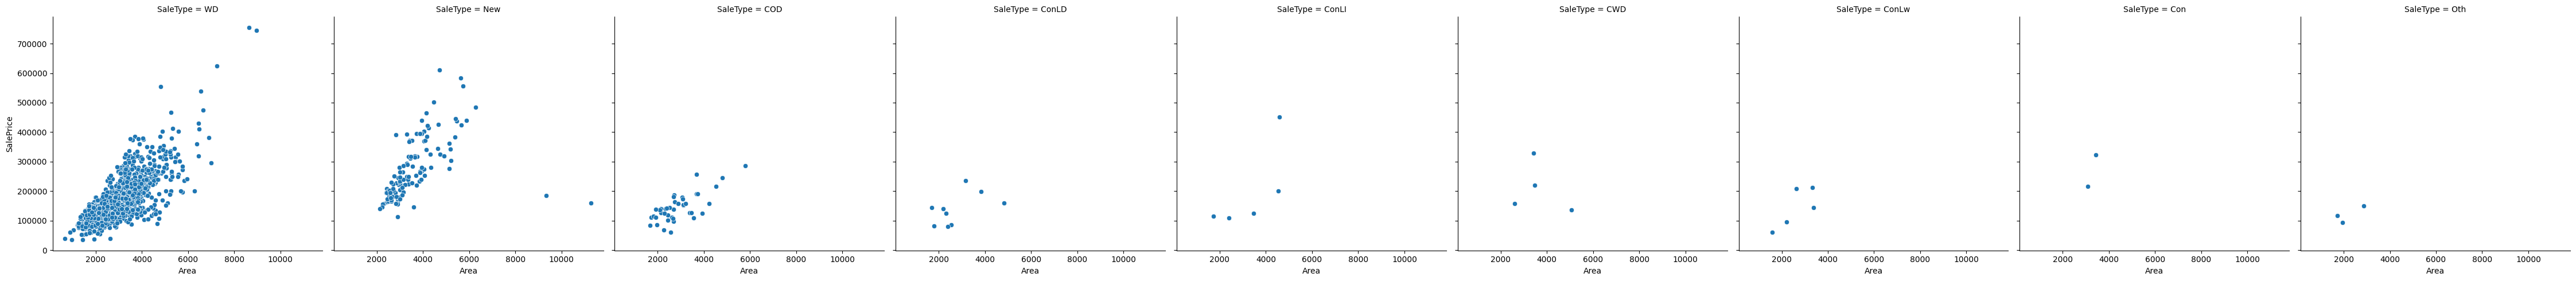

In [41]:
sns.relplot(data=df, x="Area", y="SalePrice", col="SaleType", kind="scatter")

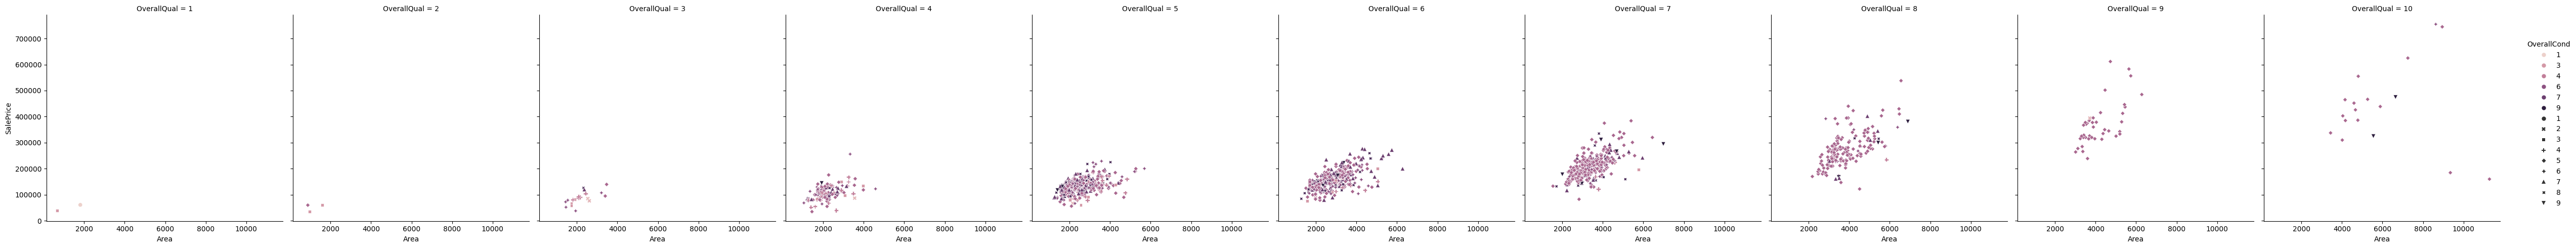

In [42]:
sns.relplot(
    data=df, x="Area", y="SalePrice",
    col="OverallQual", hue="OverallCond", style="OverallCond",
    kind="scatter"
)

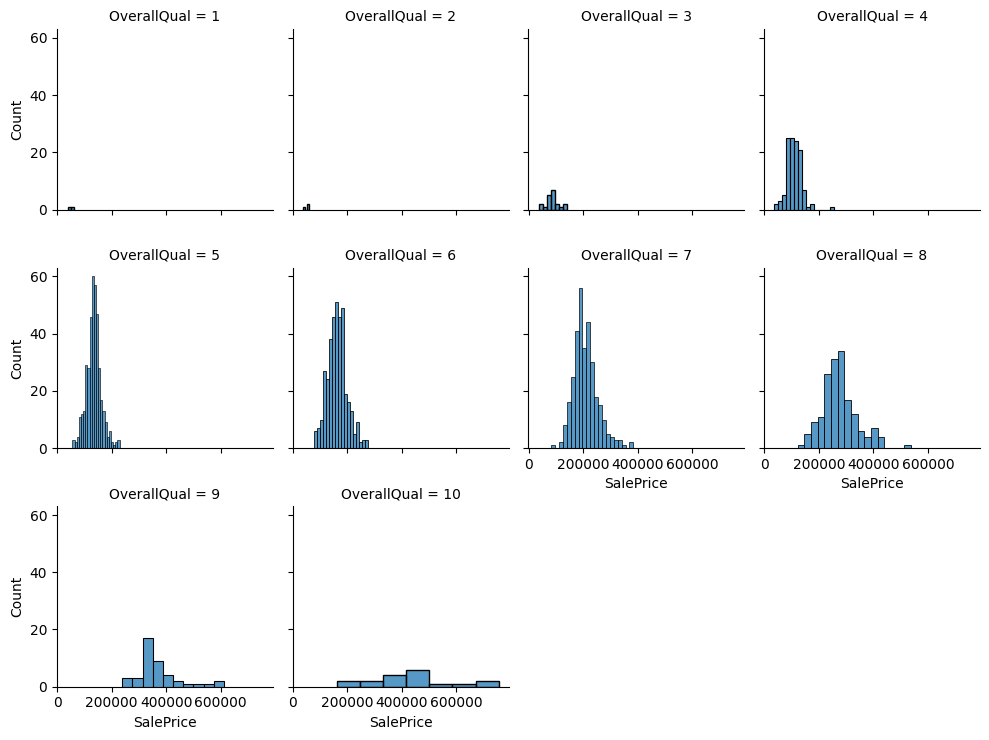

In [43]:
g = sns.FacetGrid(df, col="OverallQual", height=2.5, col_wrap=4)
g.map(sns.histplot, "SalePrice")

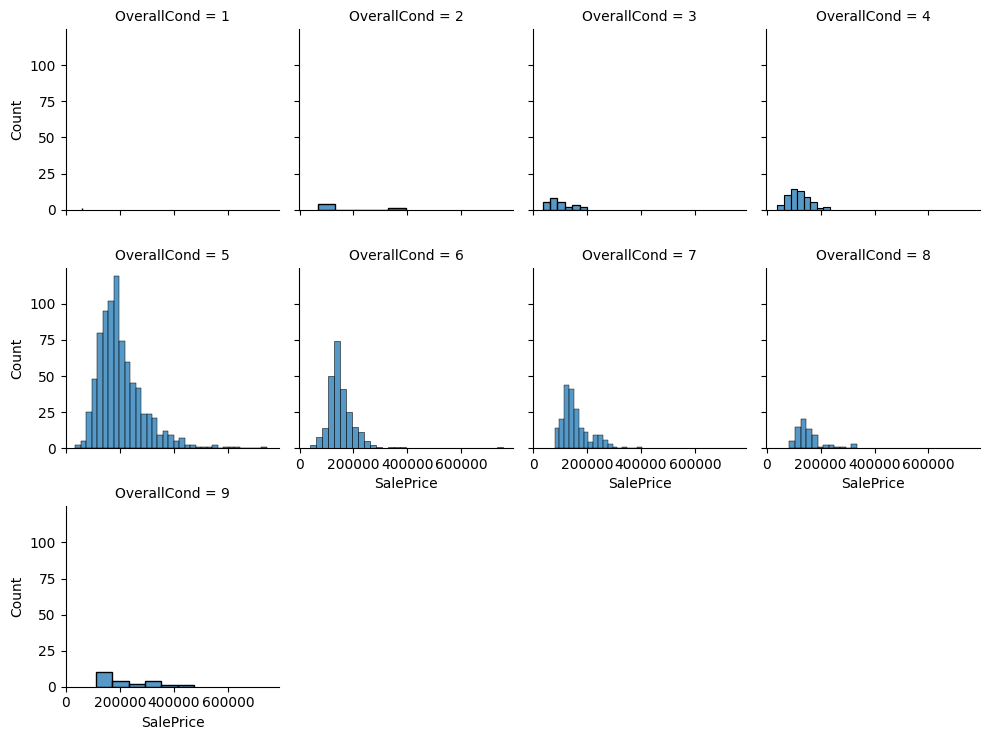

In [44]:
g = sns.FacetGrid(df, col="OverallCond", height=2.5, col_wrap=4)
g.map(sns.histplot, "SalePrice")